In [1]:
import pandas as pd

data = {
    "Date": [
        "2026-01-01", "2026-01-01", "2026-01-01",
        "2026-01-02", "2026-01-02", "2026-01-02"
    ],
    "Time": [
        "08:00", "10:00", "12:00",
        "08:00", "10:00", "12:00"
    ],
    "Day": [
        "Thursday", "Thursday", "Thursday",
        "Friday", "Friday", "Friday"
    ],
    "Location": [
        "Zone_A", "Zone_A", "Zone_A",
        "Zone_B", "Zone_B", "Zone_B"
    ],
    "Weather": [
        "Clear", "Clear", "Rain",
        "Clear", "Cloudy", "Rain"
    ],
    "Temperature": [
        28.5, 30.0, 27.5,
        29.0, 28.0, 26.5
    ],
    "Traffic_Level": [
        "High", "Medium", "Low",
        "High", "Medium", "Low"
    ],
    "Parking_Capacity": [
        500, 500, 500,
        400, 400, 400
    ],
    "Occupied_Spaces": [
        420, 350, 280,
        350, 300, 220
    ],
    "Parking_Demand": [
        435, 365, 295,
        365, 315, 235
    ]
}

df = pd.DataFrame(data)

df

,Date,Time,Day,Location,Weather,Temperature,Traffic_Level,Parking_Capacity,Occupied_Spaces,Parking_Demand
0,2026-01-01,08:00,Thursday,Zone_A,Clear,28.5,High,500,420,435
1,2026-01-01,10:00,Thursday,Zone_A,Clear,30.0,Medium,500,350,365
2,2026-01-01,12:00,Thursday,Zone_A,Rain,27.5,Low,500,280,295
3,2026-01-02,08:00,Friday,Zone_B,Clear,29.0,High,400,350,365
4,2026-01-02,10:00,Friday,Zone_B,Cloudy,28.0,Medium,400,300,315
5,2026-01-02,12:00,Friday,Zone_B,Rain,26.5,Low,400,220,235


In [2]:
# Check the first 5 rows
print(df.head())

# Check number of rows and columns
print("Shape of dataset:", df.shape)

# Check column names
print("Columns:")
print(df.columns.tolist())

# Check missing values
print("\nMissing values:")
print(df.isnull().sum())

         Date   Time       Day Location Weather  Temperature Traffic_Level  \
0  2026-01-01  08:00  Thursday   Zone_A   Clear         28.5          High   
1  2026-01-01  10:00  Thursday   Zone_A   Clear         30.0        Medium   
2  2026-01-01  12:00  Thursday   Zone_A    Rain         27.5           Low   
3  2026-01-02  08:00    Friday   Zone_B   Clear         29.0          High   
4  2026-01-02  10:00    Friday   Zone_B  Cloudy         28.0        Medium   

   Parking_Capacity  Occupied_Spaces  Parking_Demand  
0               500              420             435  
1               500              350             365  
2               500              280             295  
3               400              350             365  
4               400              300             315  
Shape of dataset: (6, 10)
Columns:
['Date', 'Time', 'Day', 'Location', 'Weather', 'Temperature', 'Traffic_Level', 'Parking_Capacity', 'Occupied_Spaces', 'Parking_Demand']

Missing values:
Date         

In [3]:
# Check number of duplicate rows
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [4]:
# Remove duplicate rows
df = df.drop_duplicates()

# Check again
print("Duplicate rows after cleaning:", df.duplicated().sum())

Duplicate rows after cleaning: 0


In [5]:
# Check numerical columns
print(df[[
    "Temperature",
    "Parking_Capacity",
    "Occupied_Spaces",
    "Parking_Demand"
]].describe())

       Temperature  Parking_Capacity  Occupied_Spaces  Parking_Demand
count     6.000000          6.000000         6.000000        6.000000
mean     28.250000        450.000000       320.000000      335.000000
std       1.214496         54.772256        68.992753       68.992753
min      26.500000        400.000000       220.000000      235.000000
25%      27.625000        400.000000       285.000000      300.000000
50%      28.250000        450.000000       325.000000      340.000000
75%      28.875000        500.000000       350.000000      365.000000
max      30.000000        500.000000       420.000000      435.000000


In [6]:
print("Negative temperatures:",
      (df["Temperature"] < 0).sum())

print("Negative parking capacity:",
      (df["Parking_Capacity"] < 0).sum())

print("Negative occupied spaces:",
      (df["Occupied_Spaces"] < 0).sum())

print("Negative parking demand:",
      (df["Parking_Demand"] < 0).sum())

Negative temperatures: 0
Negative parking capacity: 0
Negative occupied spaces: 0
Negative parking demand: 0


In [7]:
# Find rows where occupied spaces exceed parking capacity
invalid_rows = df[
    df["Occupied_Spaces"] > df["Parking_Capacity"]
]

print("Invalid rows:", len(invalid_rows))

invalid_rows

Invalid rows: 0


,Date,Time,Day,Location,Weather,Temperature,Traffic_Level,Parking_Capacity,Occupied_Spaces,Parking_Demand


In [8]:
df = df[
    df["Occupied_Spaces"] <= df["Parking_Capacity"]
]

print("Rows after cleaning:", len(df))

Rows after cleaning: 6


In [9]:
# Convert Date to datetime format
df["Date"] = pd.to_datetime(df["Date"])

# Extract useful information from Date
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day_Number"] = df["Date"].dt.day

# Convert Time into hour
df["Hour"] = pd.to_datetime(df["Time"]).dt.hour

# Display the result
df[["Date", "Time", "Year", "Month", "Day_Number", "Hour"]]

/tmp/ipykernel_3253/3540196114.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Hour"] = pd.to_datetime(df["Time"]).dt.hour


,Date,Time,Year,Month,Day_Number,Hour
0,2026-01-01,08:00,2026,1,1,8
1,2026-01-01,10:00,2026,1,1,10
2,2026-01-01,12:00,2026,1,1,12
3,2026-01-02,08:00,2026,1,2,8
4,2026-01-02,10:00,2026,1,2,10
5,2026-01-02,12:00,2026,1,2,12


In [10]:
# Convert categorical columns into numerical columns
df = pd.get_dummies(
    df,
    columns=["Day", "Location", "Weather", "Traffic_Level"],
    drop_first=True
)

# Display the first 5 rows
df.head()

,Date,Time,Temperature,Parking_Capacity,Occupied_Spaces,Parking_Demand,Year,Month,Day_Number,Hour,Day_Thursday,Location_Zone_B,Weather_Cloudy,Weather_Rain,Traffic_Level_Low,Traffic_Level_Medium
0,2026-01-01,08:00,28.5,500,420,435,2026,1,1,8,True,False,False,False,False,False
1,2026-01-01,10:00,30.0,500,350,365,2026,1,1,10,True,False,False,False,False,True
2,2026-01-01,12:00,27.5,500,280,295,2026,1,1,12,True,False,False,True,True,False
3,2026-01-02,08:00,29.0,400,350,365,2026,1,2,8,False,True,False,False,False,False
4,2026-01-02,10:00,28.0,400,300,315,2026,1,2,10,False,True,True,False,False,True


In [11]:
print(df.columns.tolist())

['Date', 'Time', 'Temperature', 'Parking_Capacity', 'Occupied_Spaces', 'Parking_Demand', 'Year', 'Month', 'Day_Number', 'Hour', 'Day_Thursday', 'Location_Zone_B', 'Weather_Cloudy', 'Weather_Rain', 'Traffic_Level_Low', 'Traffic_Level_Medium']


In [12]:
# Check dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Date                  6 non-null      datetime64[ns]
 1   Time                  6 non-null      object        
 2   Temperature           6 non-null      float64       
 3   Parking_Capacity      6 non-null      int64         
 4   Occupied_Spaces       6 non-null      int64         
 5   Parking_Demand        6 non-null      int64         
 6   Year                  6 non-null      int32         
 7   Month                 6 non-null      int32         
 8   Day_Number            6 non-null      int32         
 9   Hour                  6 non-null      int32         
 10  Day_Thursday          6 non-null      bool          
 11  Location_Zone_B       6 non-null      bool          
 12  Weather_Cloudy        6 non-null      bool          
 13  Weather_Rain          6 

In [13]:
# Check for missing values again
print(df.isnull().sum())

Date                    0
Time                    0
Temperature             0
Parking_Capacity        0
Occupied_Spaces         0
Parking_Demand          0
Year                    0
Month                   0
Day_Number              0
Hour                    0
Day_Thursday            0
Location_Zone_B         0
Weather_Cloudy          0
Weather_Rain            0
Traffic_Level_Low       0
Traffic_Level_Medium    0
dtype: int64


In [14]:
# View the cleaned dataset
df.head()

,Date,Time,Temperature,Parking_Capacity,Occupied_Spaces,Parking_Demand,Year,Month,Day_Number,Hour,Day_Thursday,Location_Zone_B,Weather_Cloudy,Weather_Rain,Traffic_Level_Low,Traffic_Level_Medium
0,2026-01-01,08:00,28.5,500,420,435,2026,1,1,8,True,False,False,False,False,False
1,2026-01-01,10:00,30.0,500,350,365,2026,1,1,10,True,False,False,False,False,True
2,2026-01-01,12:00,27.5,500,280,295,2026,1,1,12,True,False,False,True,True,False
3,2026-01-02,08:00,29.0,400,350,365,2026,1,2,8,False,True,False,False,False,False
4,2026-01-02,10:00,28.0,400,300,315,2026,1,2,10,False,True,True,False,False,True


In [16]:
# Input features
X = df.drop("Parking_Demand", axis=1)

# Target variable
y = df["Parking_Demand"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (6, 15)
y shape: (6,)


In [17]:
print("Input features:")
print(X.head())

print("\nTarget:")
print(y.head())

Input features:
        Date   Time  Temperature  Parking_Capacity  Occupied_Spaces  Year  \
0 2026-01-01  08:00         28.5               500              420  2026   
1 2026-01-01  10:00         30.0               500              350  2026   
2 2026-01-01  12:00         27.5               500              280  2026   
3 2026-01-02  08:00         29.0               400              350  2026   
4 2026-01-02  10:00         28.0               400              300  2026   

   Month  Day_Number  Hour  Day_Thursday  Location_Zone_B  Weather_Cloudy  \
0      1           1     8          True            False           False   
1      1           1    10          True            False           False   
2      1           1    12          True            False           False   
3      1           2     8         False             True           False   
4      1           2    10         False             True            True   

   Weather_Rain  Traffic_Level_Low  Traffic_Level_Medium  

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (4, 15)
Testing data: (2, 15)


In [20]:
# Remove Date and Time from the machine-learning features
X = df.drop(["Parking_Demand", "Date", "Time"], axis=1)

# Target variable
y = df["Parking_Demand"]

# Split the data again
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

# Scale the features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training data scaled:", X_train_scaled.shape)
print("Testing data scaled:", X_test_scaled.shape)

Training data scaled: (4, 13)
Testing data scaled: (2, 13)


In [21]:
from sklearn.linear_model import ElasticNet

# Create the Elastic Net model
model = ElasticNet(
    alpha=0.1,
    l1_ratio=0.5,
    random_state=42
)

# Train the model
model.fit(X_train_scaled, y_train)

print("Elastic Net model trained successfully!")

Elastic Net model trained successfully!


In [22]:
# Make predictions
y_pred = model.predict(X_test_scaled)

# Display actual and predicted values
results = pd.DataFrame({
    "Actual_Parking_Demand": y_test.values,
    "Predicted_Parking_Demand": y_pred
})

print(results)

   Actual_Parking_Demand  Predicted_Parking_Demand
0                    435                403.292972
1                    365                389.099745


In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation")
print("-----------------")
print("MAE  :", mae)
print("MSE  :", mse)
print("RMSE :", rmse)
print("R²   :", r2)

Model Evaluation
-----------------
MAE  : 27.903386454173017
MSE  : 793.0666664996672
RMSE : 28.16143935418904
R²   : 0.35259863959210835


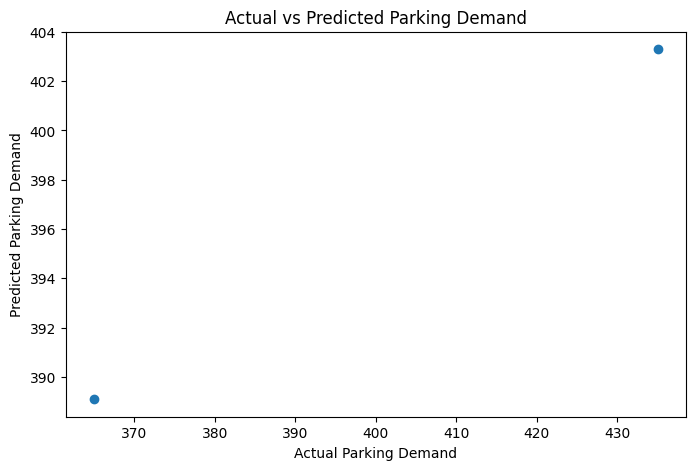

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Parking Demand")
plt.ylabel("Predicted Parking Demand")
plt.title("Actual vs Predicted Parking Demand")

plt.show()

In [25]:
# Get feature names
feature_names = X.columns

# Get Elastic Net coefficients
coefficients = model.coef_

# Create a table
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

# Sort by absolute coefficient
feature_importance["Absolute_Coefficient"] = (
    feature_importance["Coefficient"].abs()
)

feature_importance = feature_importance.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

print(feature_importance)

                 Feature  Coefficient  Absolute_Coefficient
2        Occupied_Spaces    13.653378             13.653378
0            Temperature    13.299805             13.299805
6                   Hour   -10.135714             10.135714
10          Weather_Rain    -7.106305              7.106305
11     Traffic_Level_Low    -7.083032              7.083032
1       Parking_Capacity     2.853267              2.853267
8        Location_Zone_B    -2.834176              2.834176
5             Day_Number    -2.827370              2.827370
7           Day_Thursday     2.820319              2.820319
12  Traffic_Level_Medium    -1.549605              1.549605
9         Weather_Cloudy    -1.529800              1.529800
4                  Month     0.000000              0.000000
3                   Year     0.000000              0.000000


In [26]:
# Save cleaned dataset as CSV
df.to_csv("cleaned_parking_demand.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [27]:
import os

print(os.path.exists("cleaned_parking_demand.csv"))

True


In [28]:
from google.colab import files

files.download("cleaned_parking_demand.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [30]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 1000

data = {
    "Date": pd.date_range(start="2025-01-01", periods=n, freq="h").date,
    "Time": pd.date_range(start="2025-01-01", periods=n, freq="h").time,
    "Parking_Capacity": np.random.randint(50, 201, n),
    "Occupancy": np.random.randint(10, 201, n),
    "Temperature": np.random.uniform(15, 40, n).round(2),
    "Rainfall": np.random.uniform(0, 20, n).round(2),
    "Day_Type": np.random.choice(
        ["Weekday", "Weekend"], n, p=[0.7, 0.3]
    ),
    "Holiday": np.random.choice(
        ["Yes", "No"], n, p=[0.1, 0.9]
    )
}

df = pd.DataFrame(data)

df["Parking_Demand"] = (
    df["Occupancy"] * 0.6
    + df["Temperature"] * 1.5
    - df["Rainfall"] * 0.8
    + np.random.normal(0, 10, n)
).round(2)

df.head()

,Date,Time,Parking_Capacity,Occupancy,Temperature,Rainfall,Day_Type,Holiday,Parking_Demand
0,2025-01-01,00:00:00,152,95,17.54,7.17,Weekday,No,94.76
1,2025-01-01,01:00:00,142,72,27.15,16.09,Weekday,No,46.13
2,2025-01-01,02:00:00,64,198,21.42,5.58,Weekday,No,147.43
3,2025-01-01,03:00:00,156,113,22.12,4.21,Weekend,No,94.37
4,2025-01-01,04:00:00,121,58,22.68,19.15,Weekend,No,52.25


In [31]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

Number of rows: 1000
Number of columns: 9

Column names:
['Date', 'Time', 'Parking_Capacity', 'Occupancy', 'Temperature', 'Rainfall', 'Day_Type', 'Holiday', 'Parking_Demand']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Date              1000 non-null   object 
 1   Time              1000 non-null   object 
 2   Parking_Capacity  1000 non-null   int64  
 3   Occupancy         1000 non-null   int64  
 4   Temperature       1000 non-null   float64
 5   Rainfall          1000 non-null   float64
 6   Day_Type          1000 non-null   object 
 7   Holiday           1000 non-null   object 
 8   Parking_Demand    1000 non-null   float64
dtypes: float64(3), int64(2), object(4)
memory usage: 70.4+ KB


In [32]:
# Save the new large dataset
df.to_csv("parking_demand_1000_rows.csv", index=False)

print("Dataset saved successfully!")
print("Rows:", len(df))

Dataset saved successfully!
Rows: 1000


In [33]:
# Load the new parking demand dataset

df = pd.read_csv("parking_demand_1000_rows.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (1000, 9)


,Date,Time,Parking_Capacity,Occupancy,Temperature,Rainfall,Day_Type,Holiday,Parking_Demand
0,2025-01-01,00:00:00,152,95,17.54,7.17,Weekday,No,94.76
1,2025-01-01,01:00:00,142,72,27.15,16.09,Weekday,No,46.13
2,2025-01-01,02:00:00,64,198,21.42,5.58,Weekday,No,147.43
3,2025-01-01,03:00:00,156,113,22.12,4.21,Weekend,No,94.37
4,2025-01-01,04:00:00,121,58,22.68,19.15,Weekend,No,52.25


In [34]:
# Check for missing values

print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Date                0
Time                0
Parking_Capacity    0
Occupancy           0
Temperature         0
Rainfall            0
Day_Type            0
Holiday             0
Parking_Demand      0
dtype: int64


In [35]:
# Check for duplicate rows

print("Duplicate rows before removal:", df.duplicated().sum())

# Remove duplicates
df = df.drop_duplicates()

print("Duplicate rows after removal:", df.duplicated().sum())
print("Rows remaining:", len(df))

Duplicate rows before removal: 0
Duplicate rows after removal: 0
Rows remaining: 1000


In [36]:
# Check for invalid values

print("Checking invalid values...\n")

print("Parking Capacity <= 0:", (df["Parking_Capacity"] <= 0).sum())
print("Occupancy < 0:", (df["Occupancy"] < 0).sum())
print("Temperature outside -50 to 60:", ((df["Temperature"] < -50) | (df["Temperature"] > 60)).sum())
print("Rainfall < 0:", (df["Rainfall"] < 0).sum())
print("Parking Demand < 0:", (df["Parking_Demand"] < 0).sum())

Checking invalid values...

Parking Capacity <= 0: 0
Occupancy < 0: 0
Temperature outside -50 to 60: 0
Rainfall < 0: 0
Parking Demand < 0: 0


In [37]:
# Check whether occupancy exceeds parking capacity

capacity_errors = df[df["Occupancy"] > df["Parking_Capacity"]]

print("Parking capacity errors:", len(capacity_errors))

if len(capacity_errors) > 0:
    print("\nRows with capacity errors:")
    display(capacity_errors.head())
else:
    print("No parking capacity errors found!")

Parking capacity errors: 376

Rows with capacity errors:


,Date,Time,Parking_Capacity,Occupancy,Temperature,Rainfall,Day_Type,Holiday,Parking_Demand
2,2025-01-01,02:00:00,64,198,21.42,5.58,Weekday,No,147.43
5,2025-01-01,05:00:00,70,80,35.08,0.18,Weekend,No,92.43
8,2025-01-01,08:00:00,124,188,30.26,16.57,Weekend,No,148.97
10,2025-01-01,10:00:00,166,193,21.82,0.29,Weekday,No,143.29
16,2025-01-01,16:00:00,51,182,28.13,15.38,Weekday,Yes,147.98


In [38]:
# Fix parking capacity errors

capacity_errors_before = (df["Occupancy"] > df["Parking_Capacity"]).sum()

print("Capacity errors before fixing:", capacity_errors_before)

# Make capacity equal to occupancy wherever occupancy is higher
df.loc[
    df["Occupancy"] > df["Parking_Capacity"],
    "Parking_Capacity"
] = df.loc[
    df["Occupancy"] > df["Parking_Capacity"],
    "Occupancy"
]

capacity_errors_after = (df["Occupancy"] > df["Parking_Capacity"]).sum()

print("Capacity errors after fixing:", capacity_errors_after)

Capacity errors before fixing: 376
Capacity errors after fixing: 0


In [39]:
# Convert Date and Time into a single datetime column

df["DateTime"] = pd.to_datetime(
    df["Date"].astype(str) + " " + df["Time"].astype(str)
)

print("Date and Time converted successfully!")

df[["Date", "Time", "DateTime"]].head()

Date and Time converted successfully!


,Date,Time,DateTime
0,2025-01-01,00:00:00,2025-01-01 00:00:00
1,2025-01-01,01:00:00,2025-01-01 01:00:00
2,2025-01-01,02:00:00,2025-01-01 02:00:00
3,2025-01-01,03:00:00,2025-01-01 03:00:00
4,2025-01-01,04:00:00,2025-01-01 04:00:00


In [40]:
# Extract useful features from DateTime

df["Hour"] = df["DateTime"].dt.hour
df["Day"] = df["DateTime"].dt.day
df["Month"] = df["DateTime"].dt.month
df["Day_of_Week"] = df["DateTime"].dt.dayofweek

print("Date and time features extracted successfully!")

df[["DateTime", "Hour", "Day", "Month", "Day_of_Week"]].head()

Date and time features extracted successfully!


,DateTime,Hour,Day,Month,Day_of_Week
0,2025-01-01 00:00:00,0,1,1,2
1,2025-01-01 01:00:00,1,1,1,2
2,2025-01-01 02:00:00,2,1,1,2
3,2025-01-01 03:00:00,3,1,1,2
4,2025-01-01 04:00:00,4,1,1,2


In [41]:
# Encode categorical columns

df["Day_Type"] = df["Day_Type"].map({
    "Weekday": 0,
    "Weekend": 1
})

df["Holiday"] = df["Holiday"].map({
    "No": 0,
    "Yes": 1
})

print("Categorical data encoded successfully!")

df[["Day_Type", "Holiday"]].head()

Categorical data encoded successfully!


,Day_Type,Holiday
0,0,0
1,0,0
2,0,0
3,1,0
4,1,0


In [42]:
# Check the cleaned dataset

print("Dataset shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nDataset preview:")
display(df.head())

print("\nDataset information:")
df.info()

Dataset shape: (1000, 14)

Missing values:
Date                0
Time                0
Parking_Capacity    0
Occupancy           0
Temperature         0
Rainfall            0
Day_Type            0
Holiday             0
Parking_Demand      0
DateTime            0
Hour                0
Day                 0
Month               0
Day_of_Week         0
dtype: int64

Duplicate rows: 0

Dataset preview:


,Date,Time,Parking_Capacity,Occupancy,Temperature,Rainfall,Day_Type,Holiday,Parking_Demand,DateTime,Hour,Day,Month,Day_of_Week
0,2025-01-01,00:00:00,152,95,17.54,7.17,0,0,94.76,2025-01-01 00:00:00,0,1,1,2
1,2025-01-01,01:00:00,142,72,27.15,16.09,0,0,46.13,2025-01-01 01:00:00,1,1,1,2
2,2025-01-01,02:00:00,198,198,21.42,5.58,0,0,147.43,2025-01-01 02:00:00,2,1,1,2
3,2025-01-01,03:00:00,156,113,22.12,4.21,1,0,94.37,2025-01-01 03:00:00,3,1,1,2
4,2025-01-01,04:00:00,121,58,22.68,19.15,1,0,52.25,2025-01-01 04:00:00,4,1,1,2



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Date              1000 non-null   object        
 1   Time              1000 non-null   object        
 2   Parking_Capacity  1000 non-null   int64         
 3   Occupancy         1000 non-null   int64         
 4   Temperature       1000 non-null   float64       
 5   Rainfall          1000 non-null   float64       
 6   Day_Type          1000 non-null   int64         
 7   Holiday           1000 non-null   int64         
 8   Parking_Demand    1000 non-null   float64       
 9   DateTime          1000 non-null   datetime64[ns]
 10  Hour              1000 non-null   int32         
 11  Day               1000 non-null   int32         
 12  Month             1000 non-null   int32         
 13  Day_of_Week       1000 non-null   int32         
dtypes: 

In [43]:
# Separate features (X) and target (y)

X = df[
    [
        "Parking_Capacity",
        "Occupancy",
        "Temperature",
        "Rainfall",
        "Day_Type",
        "Holiday",
        "Hour",
        "Day",
        "Month",
        "Day_of_Week"
    ]
]

y = df["Parking_Demand"]

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

Features (X) shape: (1000, 10)
Target (y) shape: (1000,)

Features:
['Parking_Capacity', 'Occupancy', 'Temperature', 'Rainfall', 'Day_Type', 'Holiday', 'Hour', 'Day', 'Month', 'Day_of_Week']

Target:
Parking_Demand


In [44]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTesting data:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Training data:
X_train: (800, 10)
y_train: (800,)

Testing data:
X_test: (200, 10)
y_test: (200,)


In [45]:
from sklearn.preprocessing import StandardScaler

# Create the scaler
scaler = StandardScaler()

# Fit only on training data and transform both datasets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully!")

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

Feature scaling completed successfully!
X_train_scaled shape: (800, 10)
X_test_scaled shape: (200, 10)


In [46]:
from sklearn.linear_model import ElasticNet

# Create the Elastic Net model
model = ElasticNet(
    alpha=0.1,
    l1_ratio=0.5,
    random_state=42
)

# Train the model
model.fit(X_train_scaled, y_train)

print("Elastic Net model trained successfully!")
print("Alpha:", model.alpha)
print("L1 Ratio:", model.l1_ratio)

Elastic Net model trained successfully!
Alpha: 0.1
L1 Ratio: 0.5


In [47]:
# Make predictions using the trained Elastic Net model

y_pred = model.predict(X_test_scaled)

print("Predictions generated successfully!")
print("Number of predictions:", len(y_pred))

print("\nFirst 10 predictions:")
print(y_pred[:10])

Predictions generated successfully!
Number of predictions: 200

First 10 predictions:
[141.21359879  75.20227889 118.07298984  96.14560906  86.64972982
  91.37419866  77.2023518  100.52466107  89.94655242 131.42080045]


In [48]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate evaluation metrics

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Elastic Net Model Evaluation")
print("----------------------------")
print("MAE  :", round(mae, 2))
print("MSE  :", round(mse, 2))
print("RMSE :", round(rmse, 2))
print("R²   :", round(r2, 2))

Elastic Net Model Evaluation
----------------------------
MAE  : 7.02
MSE  : 86.69
RMSE : 9.31
R²   : 0.94


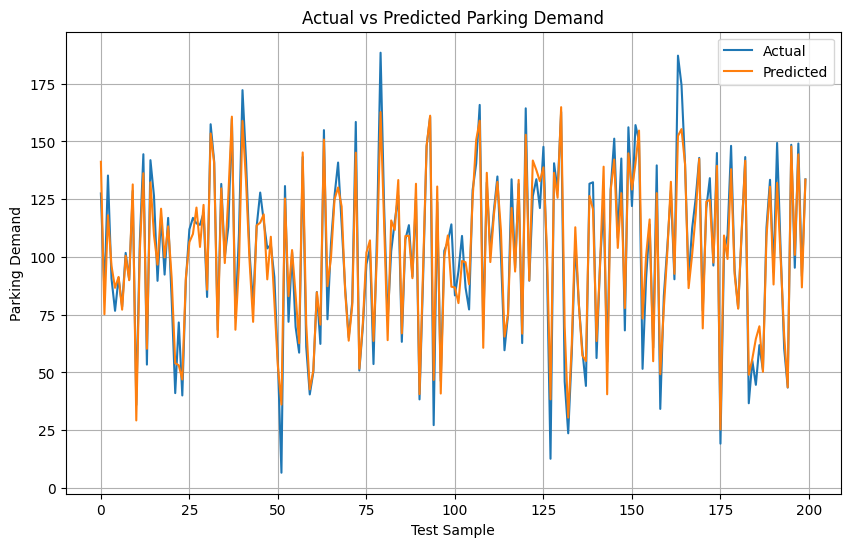

In [49]:
import matplotlib.pyplot as plt

# Plot Actual vs Predicted values

plt.figure(figsize=(10, 6))

plt.plot(
    range(len(y_test)),
    y_test.values,
    label="Actual"
)

plt.plot(
    range(len(y_pred)),
    y_pred,
    label="Predicted"
)

plt.xlabel("Test Sample")
plt.ylabel("Parking Demand")
plt.title("Actual vs Predicted Parking Demand")
plt.legend()
plt.grid(True)

plt.show()

In [50]:
# Feature importance from Elastic Net coefficients

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

# Calculate absolute importance
feature_importance["Importance"] = feature_importance["Coefficient"].abs()

# Sort from highest to lowest
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Feature Importance:")
display(feature_importance)

Feature Importance:


,Feature,Coefficient,Importance
1,Occupancy,30.970287,30.970287
2,Temperature,9.935253,9.935253
3,Rainfall,-4.126845,4.126845
0,Parking_Capacity,0.908774,0.908774
8,Month,-0.379964,0.379964
9,Day_of_Week,0.377376,0.377376
6,Hour,0.201509,0.201509
7,Day,-0.070382,0.070382
5,Holiday,0.068318,0.068318
4,Day_Type,0.034593,0.034593


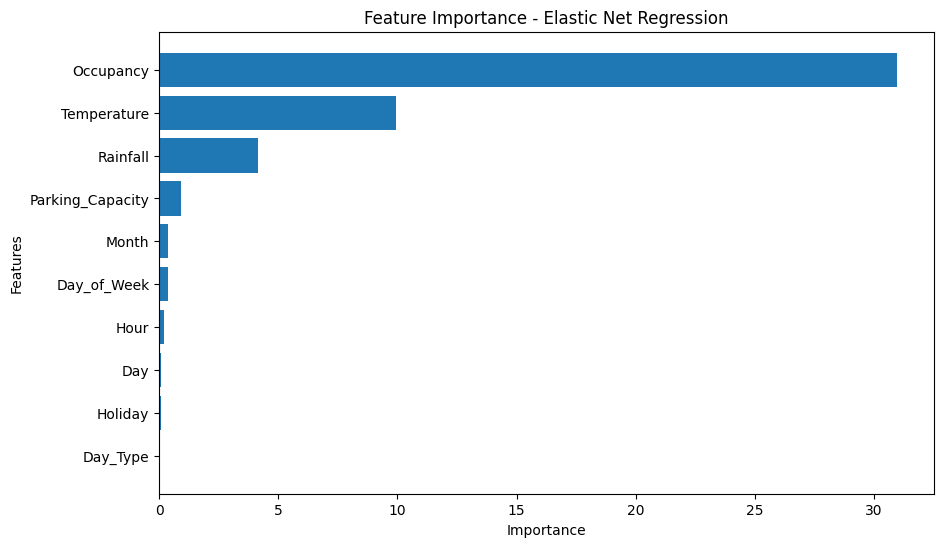

In [51]:
# Plot feature importance

plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Feature Importance - Elastic Net Regression")
plt.gca().invert_yaxis()

plt.show()

In [52]:
# Save the final cleaned dataset

df.to_csv("final_cleaned_parking_demand.csv", index=False)

print("Final cleaned dataset saved successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Final cleaned dataset saved successfully!
Rows: 1000
Columns: 14


In [53]:
import joblib

# Save the trained Elastic Net model
joblib.dump(model, "elastic_net_parking_model.pkl")

# Save the feature scaler
joblib.dump(scaler, "parking_feature_scaler.pkl")

print("Model and scaler saved successfully!")
print("Model file: elastic_net_parking_model.pkl")
print("Scaler file: parking_feature_scaler.pkl")

Model and scaler saved successfully!
Model file: elastic_net_parking_model.pkl
Scaler file: parking_feature_scaler.pkl


In [54]:
import os

files = [
    "parking_demand_1000_rows.csv",
    "final_cleaned_parking_demand.csv",
    "elastic_net_parking_model.pkl",
    "parking_feature_scaler.pkl"
]

print("FINAL PROJECT FILE CHECK")
print("-------------------------")

for file in files:
    if os.path.exists(file):
        print("✅", file)
    else:
        print("❌", file)

FINAL PROJECT FILE CHECK
-------------------------
✅ parking_demand_1000_rows.csv
✅ final_cleaned_parking_demand.csv
✅ elastic_net_parking_model.pkl
✅ parking_feature_scaler.pkl


In [55]:
from google.colab import files

files.download("final_cleaned_parking_demand.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [56]:
files.download("elastic_net_parking_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [57]:
files.download("parking_feature_scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>